In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import seaborn as sns
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.metrics import dtw
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Set folder path
folder = './Data/'

# Load all three CSV files
df_width = pd.read_csv(os.path.join(folder, 'widthConstant.csv'), header=None)
df_length = pd.read_csv(os.path.join(folder, 'lengthConstant.csv'), header=None)
df_intensity = pd.read_csv(os.path.join(folder, 'intensityConstant.csv'), header=None)

print(f"DataFrame shapes: Width {df_width.shape}, Length {df_length.shape}, Intensity {df_intensity.shape}")



/home/juls/Adaptive-Filter-for-Acoustic-Signal-Segmentation/myenv/lib/python3.10/site-packages/tslearn/bases/bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


DataFrame shapes: Width (488, 112), Length (488, 112), Intensity (488, 112)


In [2]:
# Separate metadata from measurements
metadata = df_width.iloc[:, :3].copy()
metadata.columns = ['y_coordinate', 'z_coordinate', 'power']
width_data = df_width.iloc[:, 3:-4].copy()
length_data = df_length.iloc[:, 3:-4].copy()
intensity_data = df_intensity.iloc[:, 3:-4].copy()



In [3]:
# Remove rows with maximum y coordinate
y_values = metadata['y_coordinate'].values
width_data = width_data[metadata['y_coordinate'] != y_values.max()]
length_data = length_data[metadata['y_coordinate'] != y_values.max()]
intensity_data = intensity_data[metadata['y_coordinate'] != y_values.max()]
metadata = metadata[metadata['y_coordinate'] != y_values.max()]



In [4]:
# Convert to numpy arrays 
width_array = width_data.values
length_array = length_data.values
intensity_array = intensity_data.values

# Reshape data for tslearn (samples, timestamps, features)
width_ts = width_array.reshape(width_array.shape[0], width_array.shape[1], 1)
length_ts = length_array.reshape(length_array.shape[0], length_array.shape[1], 1)
intensity_ts = intensity_array.reshape(intensity_array.shape[0], intensity_array.shape[1], 1)

# Combine features for multivariate time series (samples, timestamps, features=3)
combined_ts = np.dstack((width_ts, length_ts, intensity_ts))
combined_ts = combined_ts.reshape(combined_ts.shape[0], combined_ts.shape[1], 3)

print(f"Combined time series shape: {combined_ts.shape}")



Combined time series shape: (478, 105, 3)


In [5]:
# Scale the time series data
scaler = TimeSeriesScalerMeanVariance()
scaled_ts = scaler.fit_transform(combined_ts)



In [6]:
# Define function to compute silhouette score using DTW distance
def silhouette_dtw(X, labels):
    n_samples = len(X)
    intra_clust_dists = np.zeros(n_samples)
    nearest_clust_dists = np.zeros(n_samples)

    for i in range(n_samples):
        # Find intra-cluster distance
        same_clust = np.where(labels == labels[i])[0]
        if len(same_clust) > 1:  # More than one sample in the cluster
            intra_dists = np.array([dtw(X[i, :, :], X[j, :, :]) for j in same_clust if j != i])
            intra_clust_dists[i] = np.mean(intra_dists)

        # Find nearest cluster distance
        unique_labels = np.unique(labels)
        other_clust_dists = []
        for label in unique_labels:
            if label != labels[i]:
                other_clust = np.where(labels == label)[0]
                other_dists = np.array([dtw(X[i, :, :], X[j, :, :]) for j in other_clust])
                other_clust_dists.append(np.mean(other_dists))

        if other_clust_dists:
            nearest_clust_dists[i] = np.min(other_clust_dists)

    # Calculate silhouette
    silhouette_samples = (nearest_clust_dists - intra_clust_dists) / np.maximum(intra_clust_dists, nearest_clust_dists)
    return np.mean(silhouette_samples)



In [7]:
# Determine MAX number of clusters
MAX_NUM_CLUSTERS = 5  # Careful, DTW is expensive! 


Determining optimal number of clusters using DTW (this may take some time)...
Testing k=2...
For n_clusters = 2, the silhouette score is 0.132
Testing k=3...
For n_clusters = 3, the silhouette score is 0.075
Testing k=4...
For n_clusters = 4, the silhouette score is 0.058
Testing k=5...
For n_clusters = 5, the silhouette score is 0.053


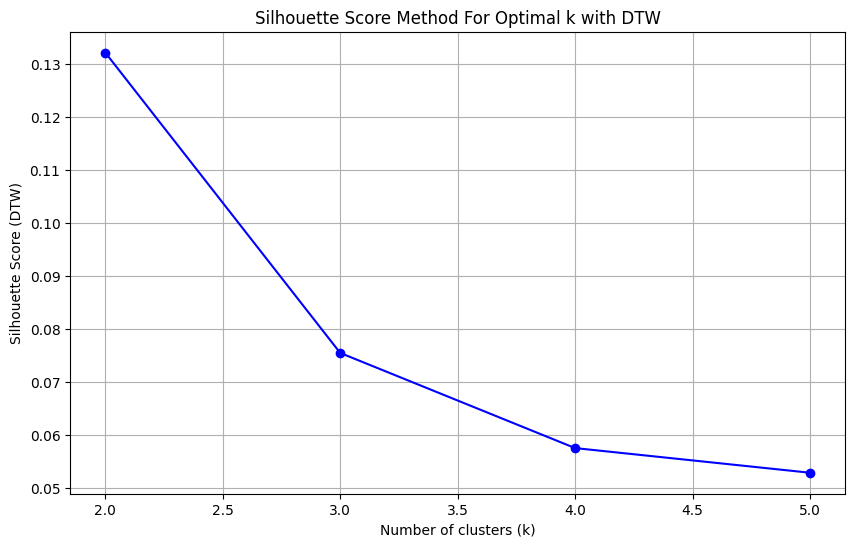

In [8]:
silhouette_scores = []

print("Determining optimal number of clusters using DTW (this may take some time)...")
for k in range(2, MAX_NUM_CLUSTERS + 1):
    print(f"Testing k={k}...")
    # Using TimeSeriesKMeans with DTW
    model = TimeSeriesKMeans(n_clusters=k, metric="dtw", random_state=42, verbose=False)
    labels = model.fit_predict(scaled_ts)

    # For small samples, compute custom silhouette
    if len(scaled_ts) <= 1000:
        score = silhouette_dtw(scaled_ts, labels)
    else:
        # For larger datasets, use a sample for silhouette calculation
        sample_idx = np.random.choice(len(scaled_ts), 1000, replace=False)
        score = silhouette_dtw(scaled_ts[sample_idx], labels[sample_idx])

    silhouette_scores.append(score)
    print(f"For n_clusters = {k}, the silhouette score is {score:.3f}")

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(range(2, MAX_NUM_CLUSTERS + 1), silhouette_scores, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score (DTW)')
plt.title('Silhouette Score Method For Optimal k with DTW')
plt.grid(True)
plt.show()



In [17]:
# Set optimal_k base on silhouette scores (choose the max)
optimal_k = 3 #np.argmax(silhouette_scores) + 2  # +2 because we started from k=2
print(f"Optimal number of clusters: {optimal_k}")



Optimal number of clusters: 3


In [18]:
# Apply TimeSeriesKMeans with the optimal number of clusters
dtw_model = TimeSeriesKMeans(n_clusters=optimal_k, metric="dtw", random_state=42, verbose=True)
cluster_labels = dtw_model.fit_predict(scaled_ts)

# Add cluster labels to the metadata
metadata['cluster'] = cluster_labels

# Calculate statistical descriptors for all features
stats = pd.DataFrame()
stats['y'] = metadata['y_coordinate']
stats['z'] = metadata['z_coordinate']
stats['power'] = metadata['power']
stats['cluster'] = metadata['cluster']

# Calculate statistics for width data
stats['mean_width'] = width_data.mean(axis=1)
stats['median_width'] = width_data.median(axis=1)
stats['std_width'] = width_data.std(axis=1)
stats['p5_width'] = width_data.quantile(0.05, axis=1)
stats['p95_width'] = width_data.quantile(0.95, axis=1)
stats['range_width'] = width_data.max(axis=1) - width_data.min(axis=1)

# Calculate statistics for length data
stats['mean_length'] = length_data.mean(axis=1)
stats['median_length'] = length_data.median(axis=1)
stats['std_length'] = length_data.std(axis=1)
stats['p5_length'] = length_data.quantile(0.05, axis=1)
stats['p95_length'] = length_data.quantile(0.95, axis=1)
stats['range_length'] = length_data.max(axis=1) - length_data.min(axis=1)

# Calculate statistics for intensity data
stats['mean_intensity'] = intensity_data.mean(axis=1)
stats['median_intensity'] = intensity_data.median(axis=1)
stats['std_intensity'] = intensity_data.std(axis=1)
stats['p5_intensity'] = intensity_data.quantile(0.05, axis=1)
stats['p95_intensity'] = intensity_data.quantile(0.95, axis=1)
stats['range_intensity'] = intensity_data.max(axis=1) - intensity_data.min(axis=1)

# Print statistics by cluster
print("\nStatistical descriptors by cluster:")
cluster_stats = stats.groupby('cluster').mean()
print(cluster_stats)



[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: 

120.319 --> 

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    0.1s


71.432 --> 

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    0.1s


...

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    0.1s


68.927 --> 

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    0.1s


68.927 --> 

Statistical descriptors by cluster:
                y         z  power  mean_width  median_width  std_width  \
cluster                                                                   
0        1.621250  0.320417  180.0   19.047937     18.858333   2.347887   
1        1.537500  0.682721  180.0   21.751261     21.367647   3.508453   
2        2.200676  0.697973  180.0   21.078936     20.536036   3.131665   

          p5_width  p95_width  range_width  mean_length  ...  std_length  \
cluster                                                  ...               
0        16.293333  22.588333    16.333333    20.986984  ...    3.080375   
1        17.738235  27.463235    23.485294    23.441737  ...    4.343414   
2        17.490991  27.016216    18.288288    23.377435  ...    4.088020   

         p5_length  p95_length  range_length  mean_intensity  \
cluster                                                        
0        16.175000   24.970000     20.016667    2.045528e+06   
1 

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 1249 tasks      | elapsed:    0.1s


In [19]:
# Count samples in each cluster
cluster_counts = stats['cluster'].value_counts().sort_index()
print("\nNumber of samples in each cluster:")
print(cluster_counts)




Number of samples in each cluster:
cluster
0    120
1    136
2    222
Name: count, dtype: int64


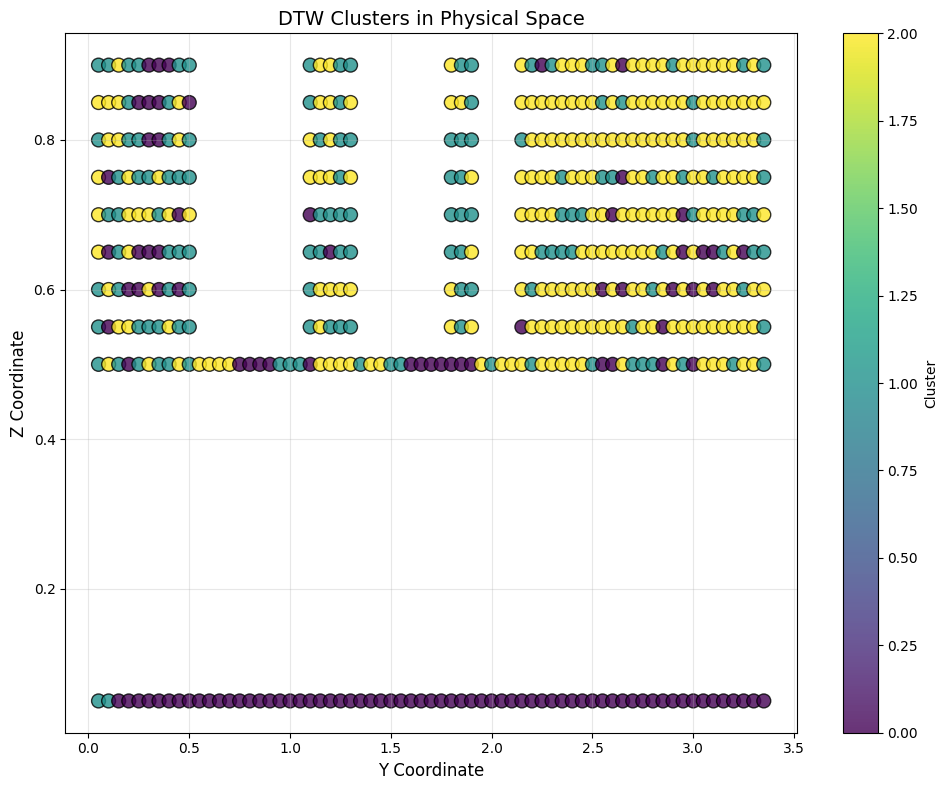

In [20]:
# Visualize the clusters in the physical space (y, z coordinates)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(stats['y'], stats['z'], c=stats['cluster'], cmap='viridis',
                     s=100, alpha=0.8, edgecolors='k')
plt.xlabel('Y Coordinate', fontsize=12)
plt.ylabel('Z Coordinate', fontsize=12)
plt.title('DTW Clusters in Physical Space', fontsize=14)
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



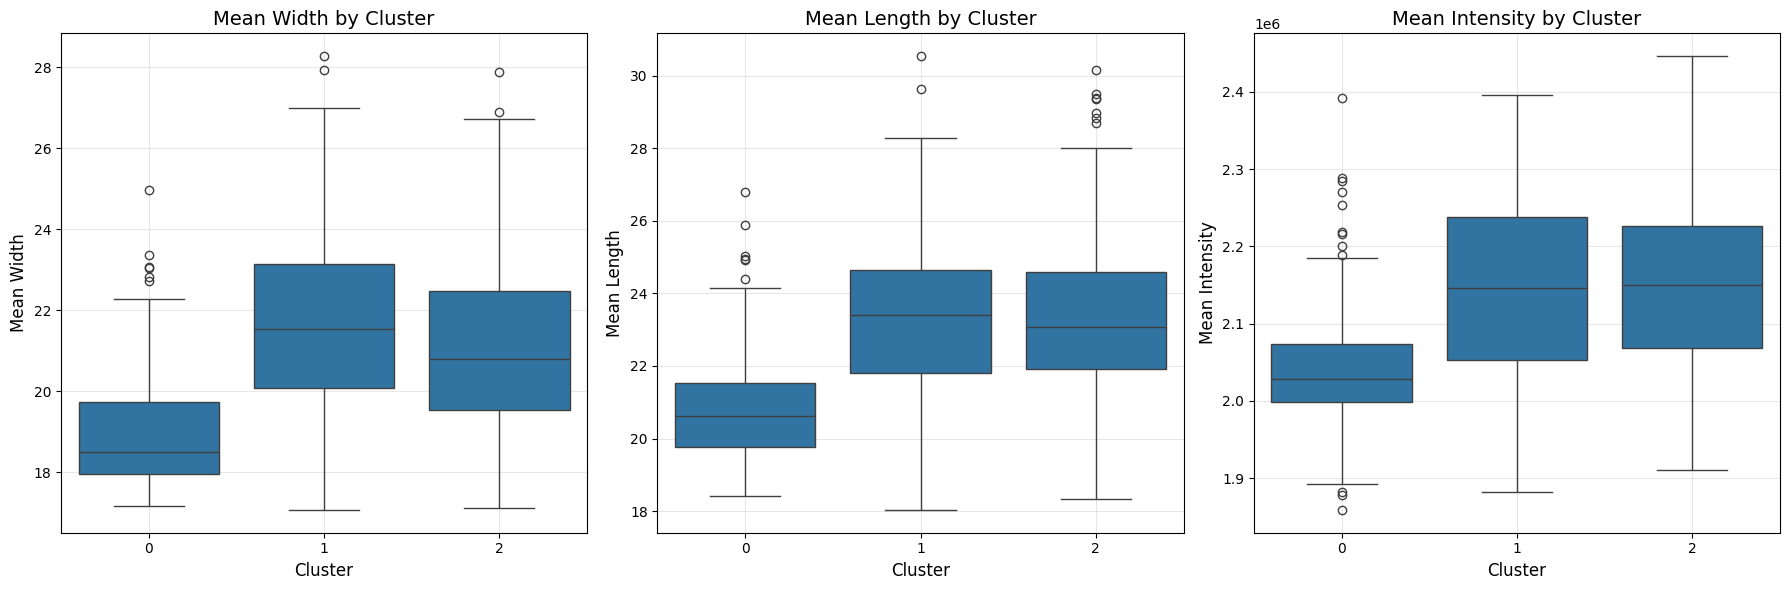

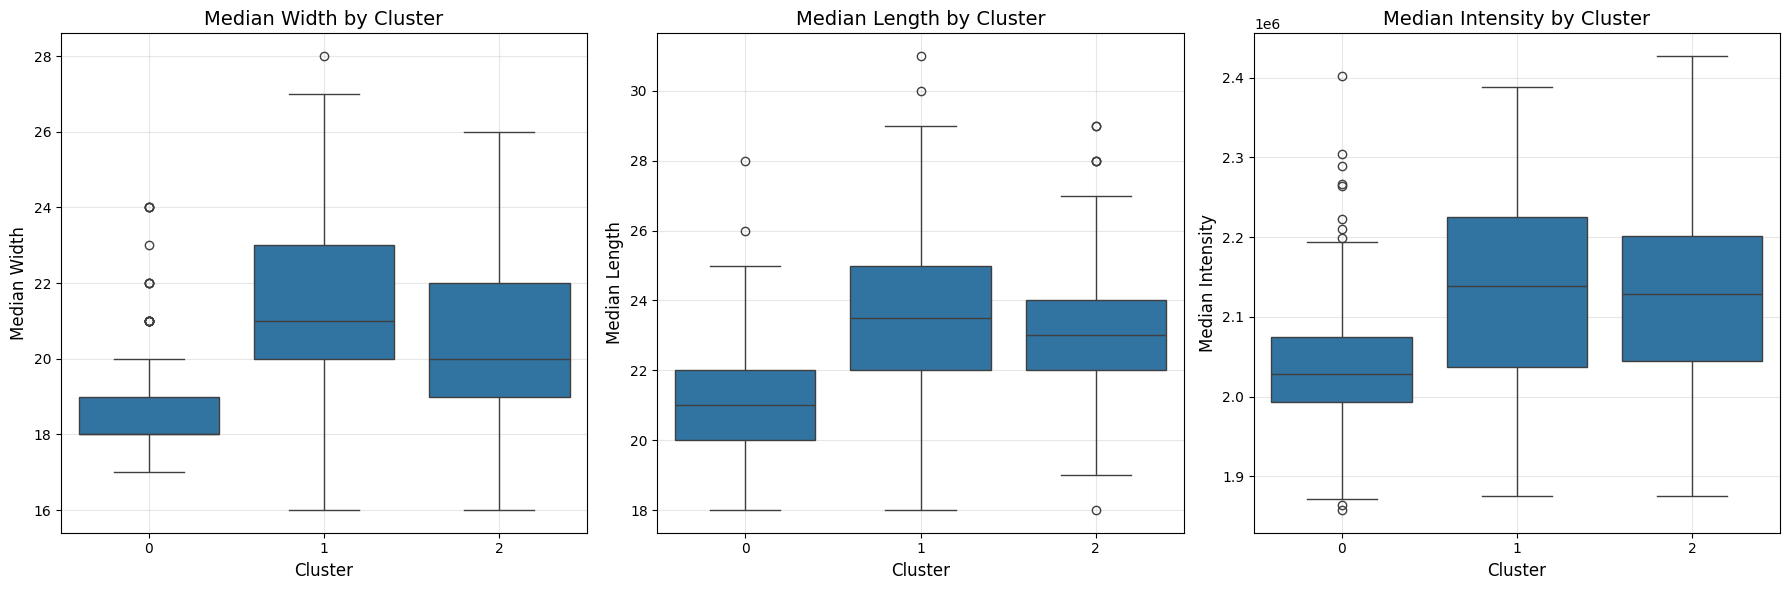

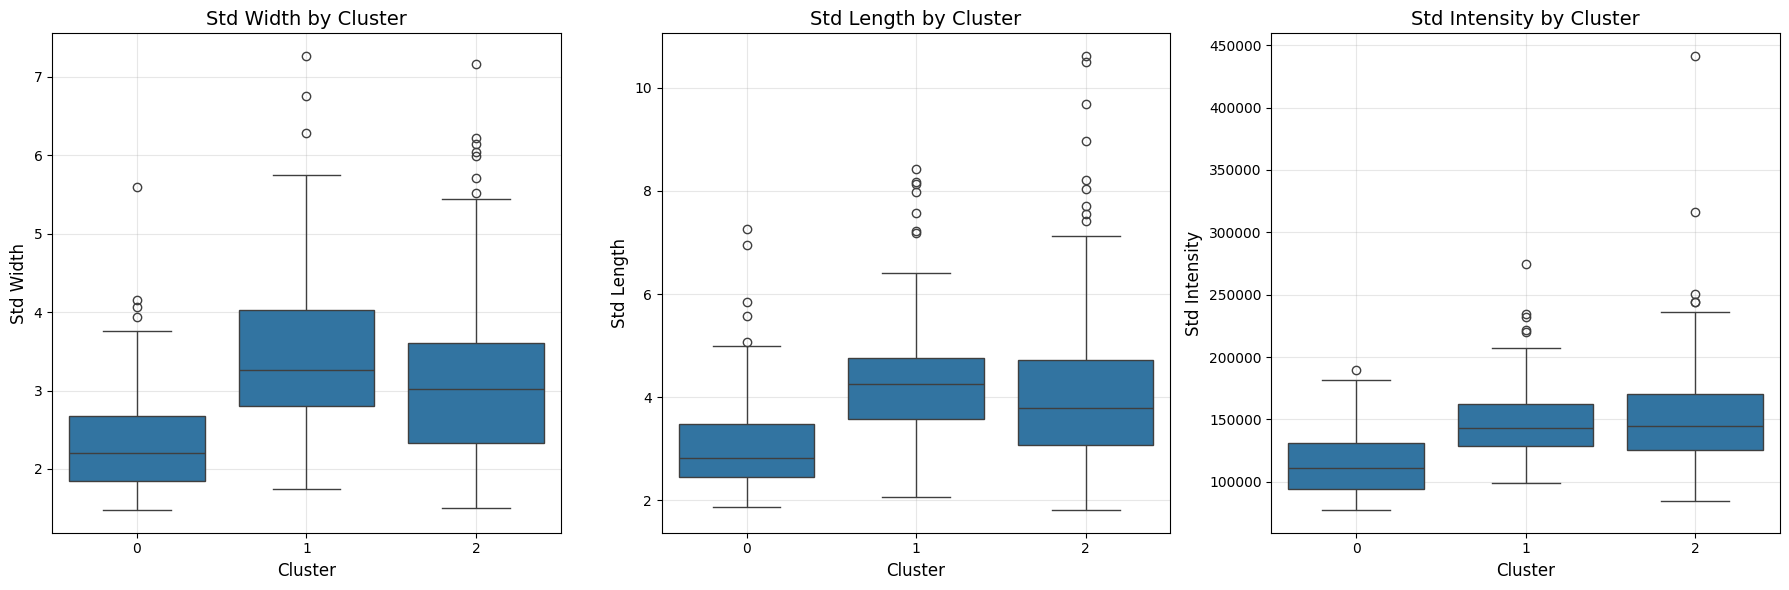

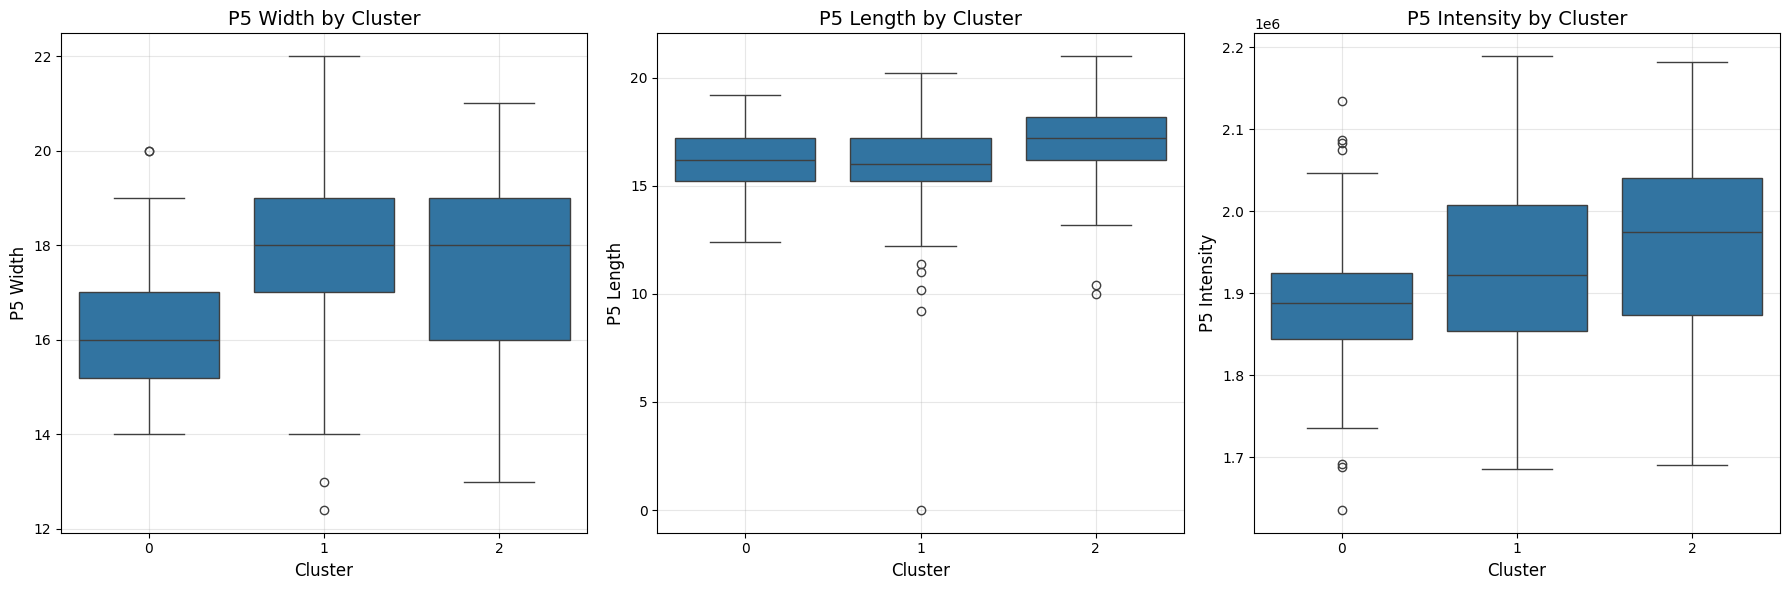

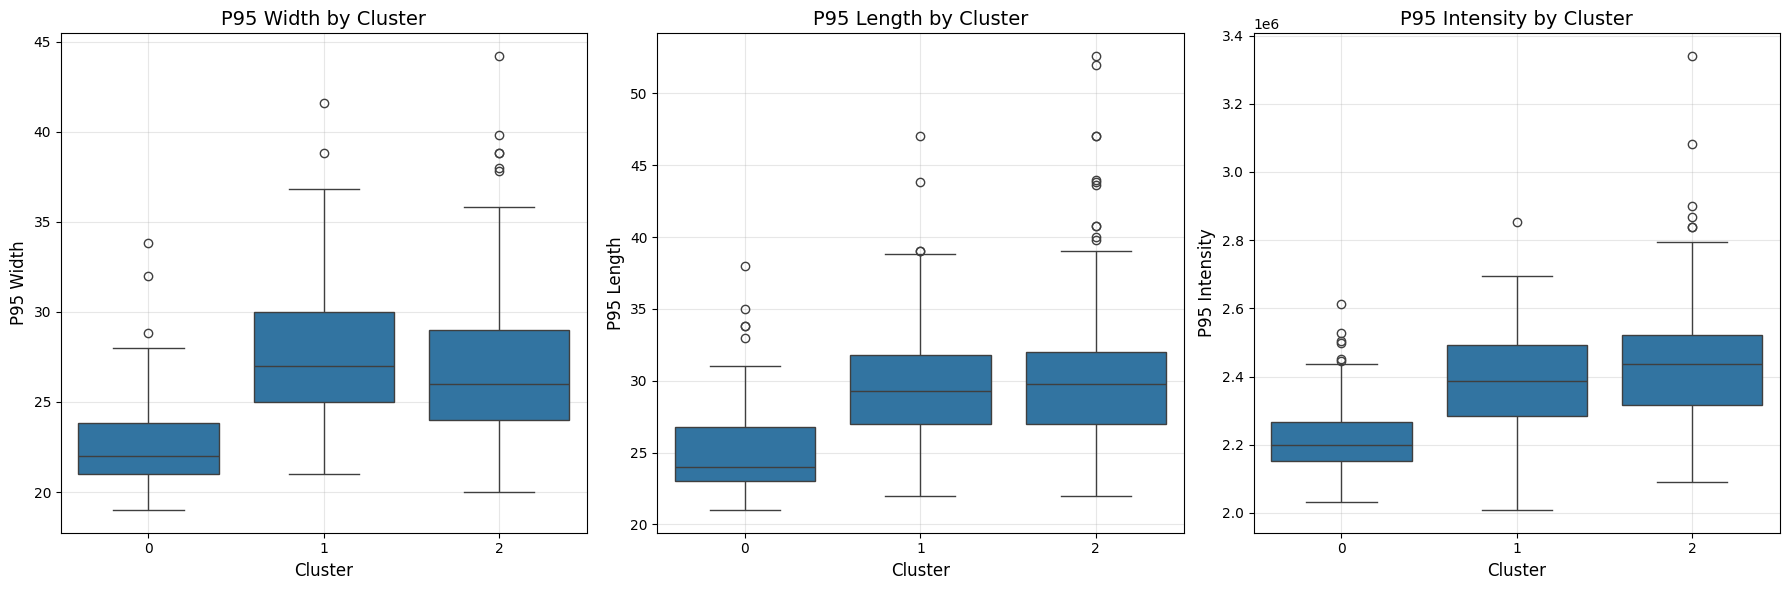

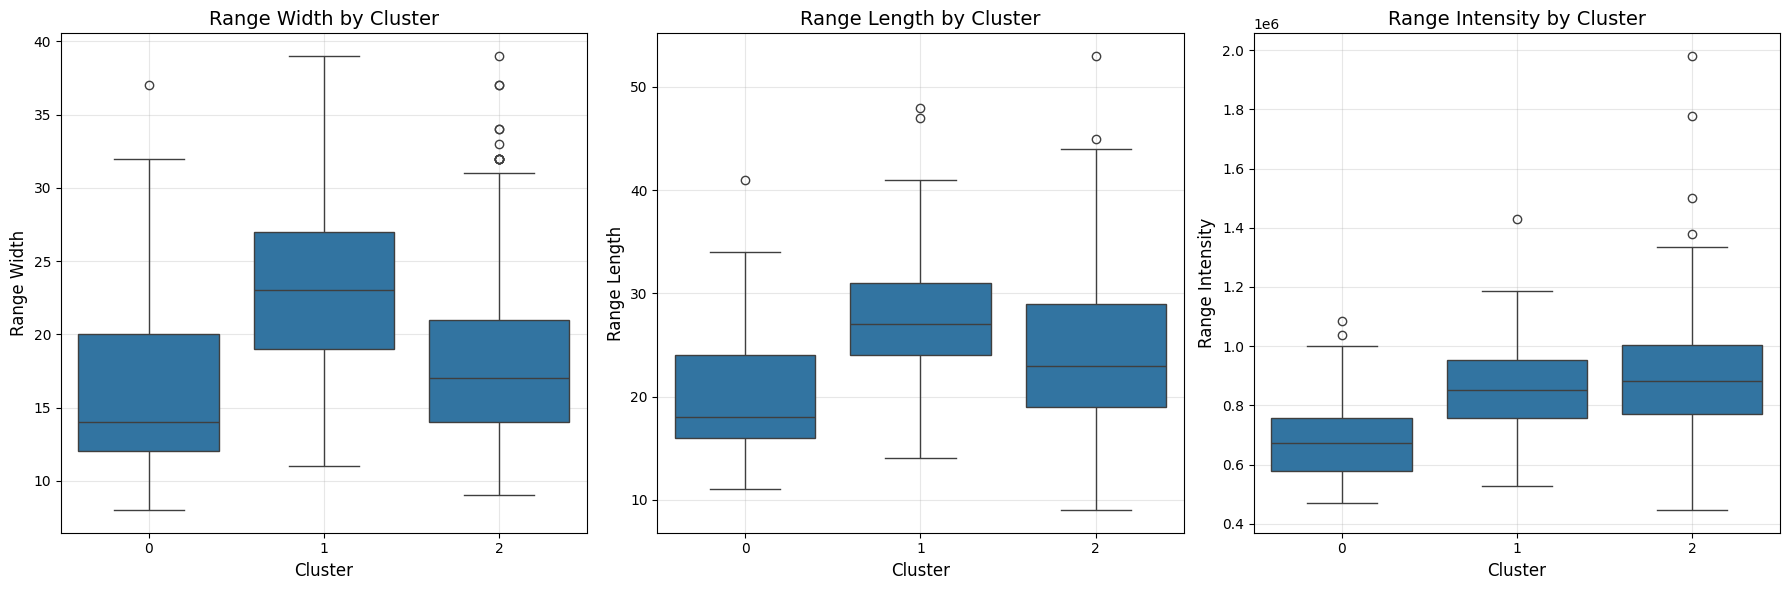

In [21]:
# Extract the cluster centers from the DTW model (in the scaled space)
dtw_centroids = dtw_model.cluster_centers_
width_centroids = dtw_centroids[:, :, 0]
length_centroids = dtw_centroids[:, :, 1]
intensity_centroids = dtw_centroids[:, :, 2]

# Inverse transform to get back to original scale (approximate)
width_mean = np.mean(width_array, axis=0)
width_std = np.std(width_array, axis=0)
length_mean = np.mean(length_array, axis=0)
length_std = np.std(length_array, axis=0)
intensity_mean = np.mean(intensity_array, axis=0)
intensity_std = np.std(intensity_array, axis=0)

width_centroids_orig = width_centroids * width_std + width_mean
length_centroids_orig = length_centroids * length_std + length_mean
intensity_centroids_orig = intensity_centroids * intensity_std + intensity_mean

# Visualize statistical descriptors for each cluster
# Group metrics by feature type
feature_types = ['width', 'length', 'intensity']
metrics = ['mean', 'median', 'std', 'p5', 'p95', 'range']

for metric in metrics:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i, feature in enumerate(feature_types):
        column_name = f"{metric}_{feature}"
        sns.boxplot(x='cluster', y=column_name, data=stats, ax=axes[i])
        axes[i].set_title(f'{metric.title()} {feature.title()} by Cluster', fontsize=14)
        axes[i].set_xlabel('Cluster', fontsize=12)
        axes[i].set_ylabel(f'{metric.title()} {feature.title()}', fontsize=12)
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()



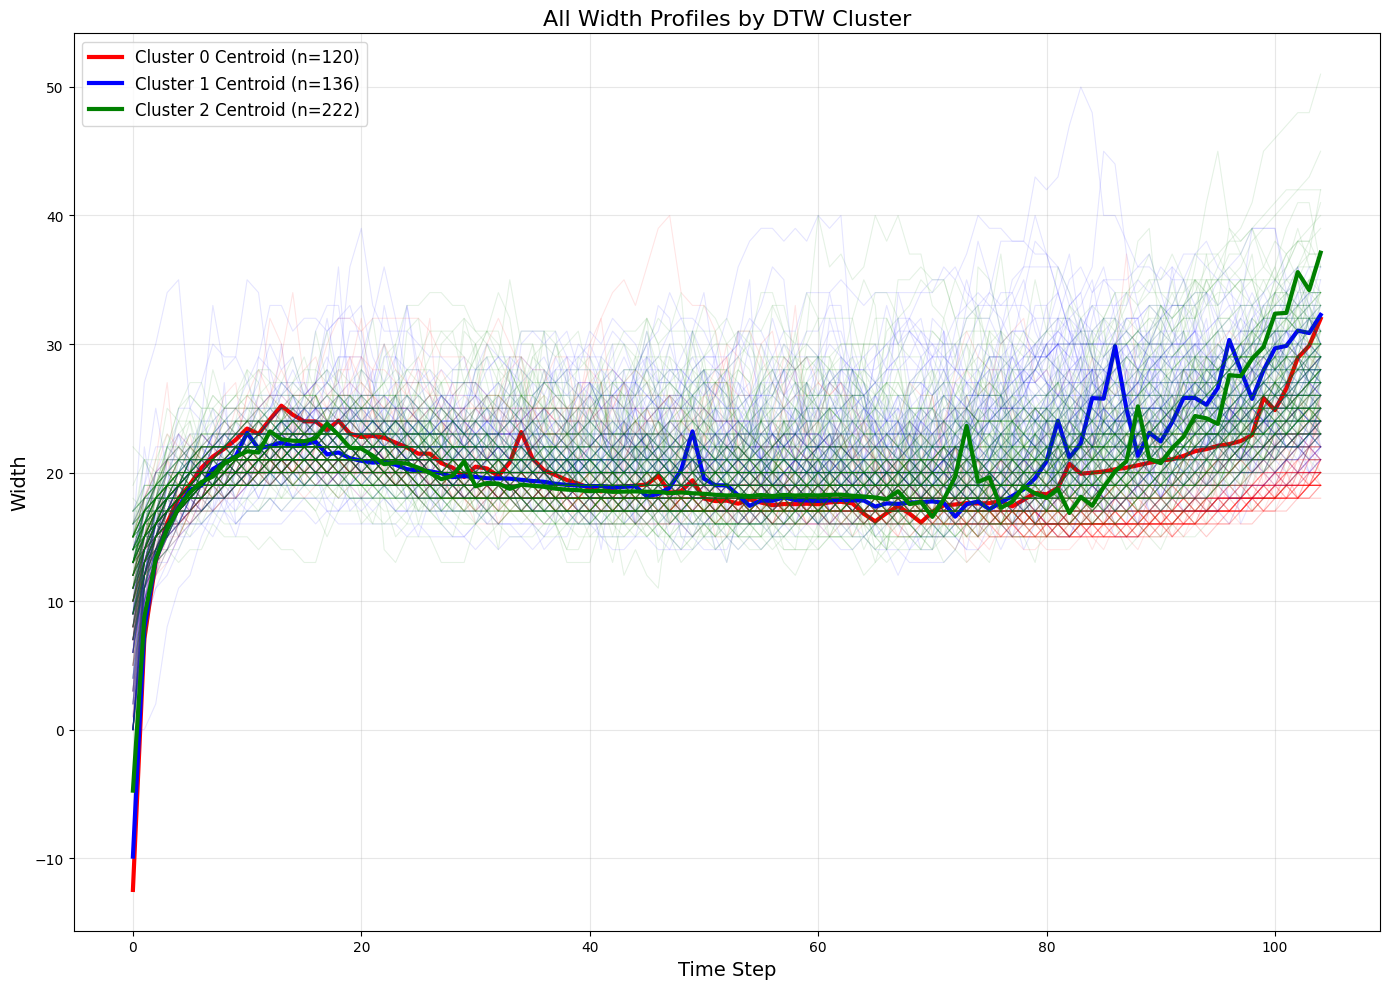

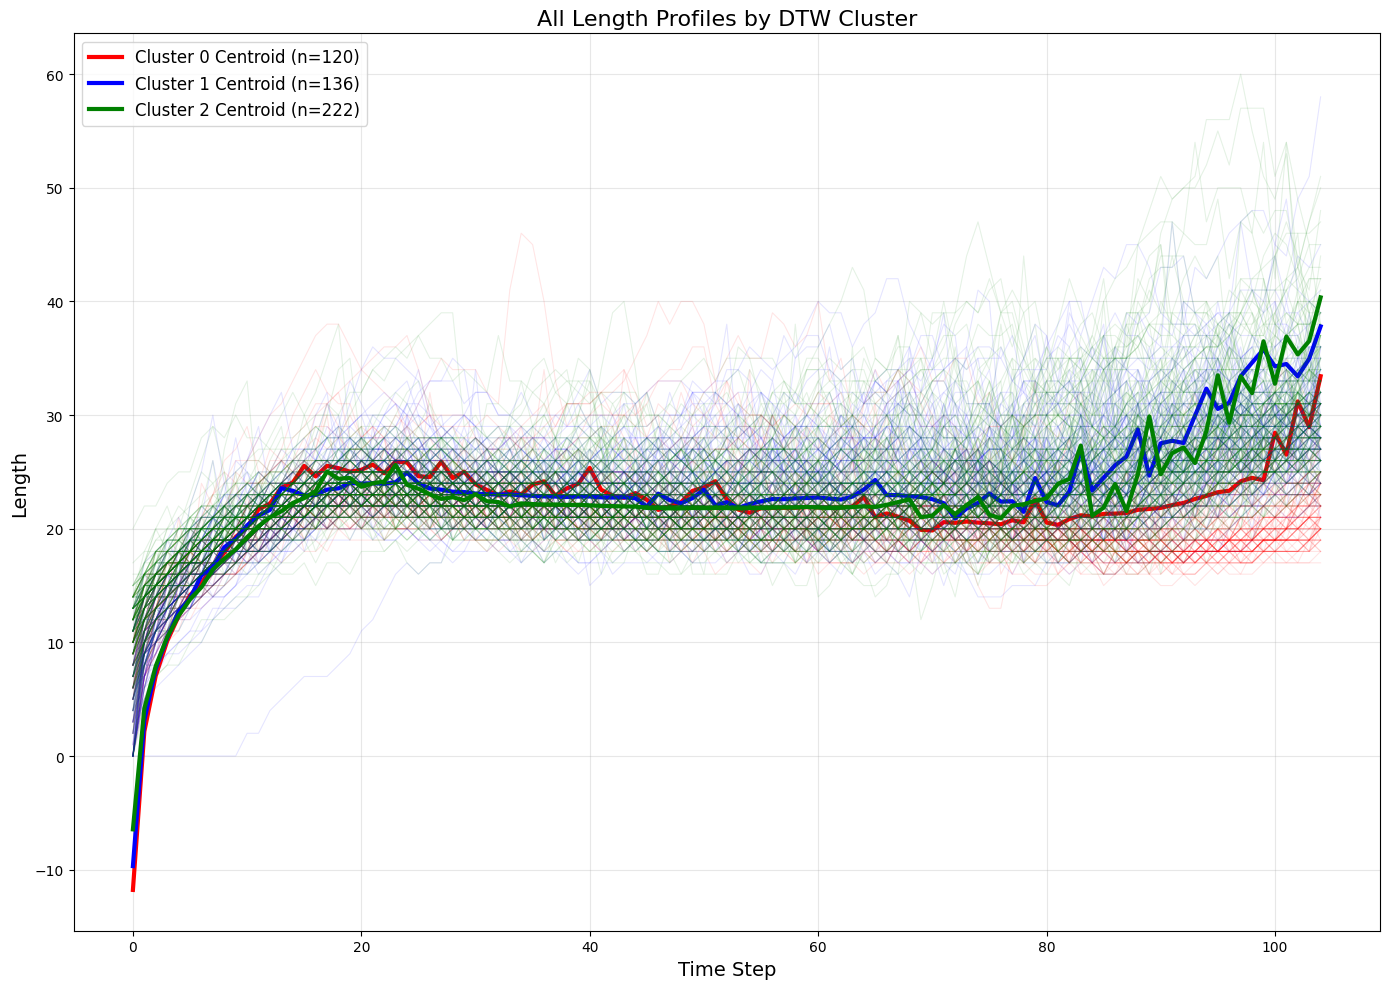

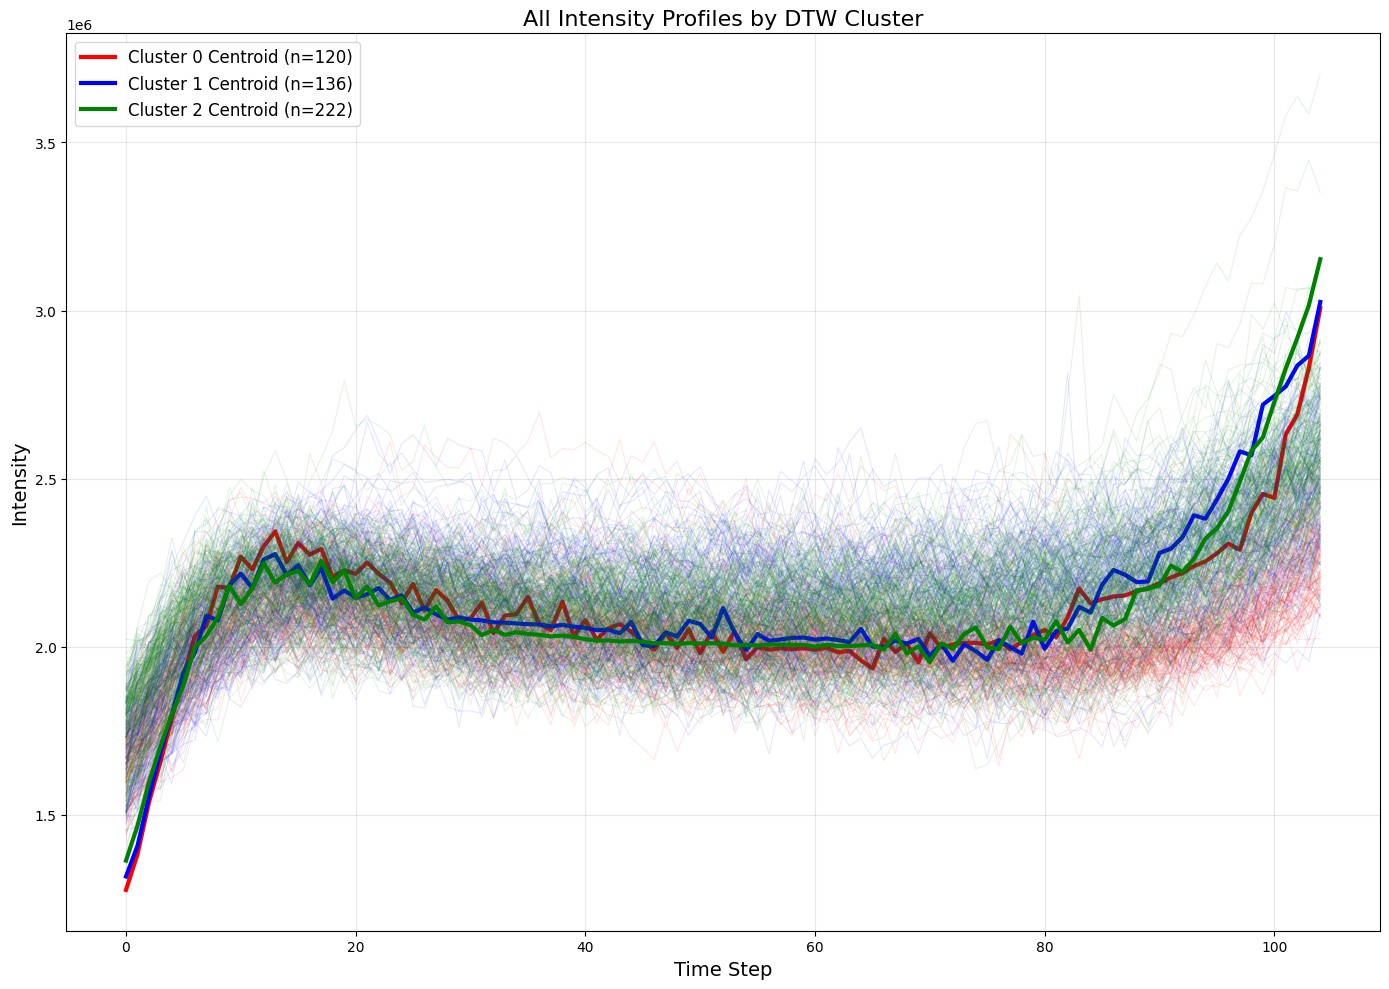

In [22]:
# Plot all profiles for each feature in a single figure
for feature_name, feature_data, centroids_orig in [
    ('Width', width_data, width_centroids_orig),
    ('Length', length_data, length_centroids_orig),
    ('Intensity', intensity_data, intensity_centroids_orig)
]:
    # Create a single figure for each feature
    plt.figure(figsize=(14, 10))

    # Define colors for each cluster
    colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'cyan']

    # Create x-axis values for plotting
    x_values = np.arange(feature_data.shape[1])

    # Plot profiles for each cluster
    for cluster_id in range(optimal_k):
        # Get profiles for this cluster
        cluster_indices = np.where(cluster_labels == cluster_id)[0]
        if len(cluster_indices) == 0:
            continue  # Skip if cluster is empty

        cluster_data = feature_data.iloc[cluster_indices]

        # Plot individual profiles with light color
        for i in range(cluster_data.shape[0]):
            plt.plot(x_values, cluster_data.iloc[i, :],
                     color=colors[cluster_id % len(colors)],
                     alpha=0.1,
                     linewidth=0.8)

        # Plot the centroid with solid color and thicker line
        plt.plot(x_values, centroids_orig[cluster_id],
                 linewidth=3,
                 color=colors[cluster_id % len(colors)],
                 label=f'Cluster {cluster_id} Centroid (n={len(cluster_indices)})')

    plt.xlabel('Time Step', fontsize=14)
    plt.ylabel(feature_name, fontsize=14)
    plt.title(f'All {feature_name} Profiles by DTW Cluster', fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



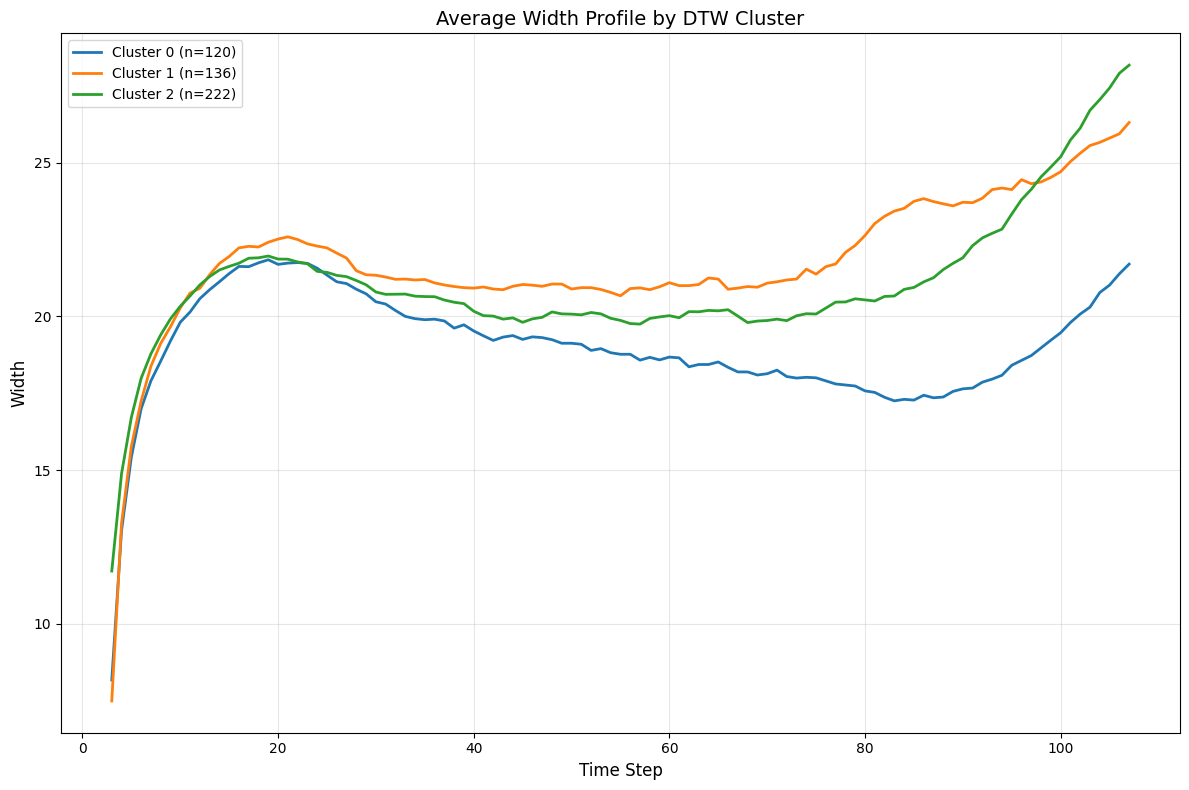

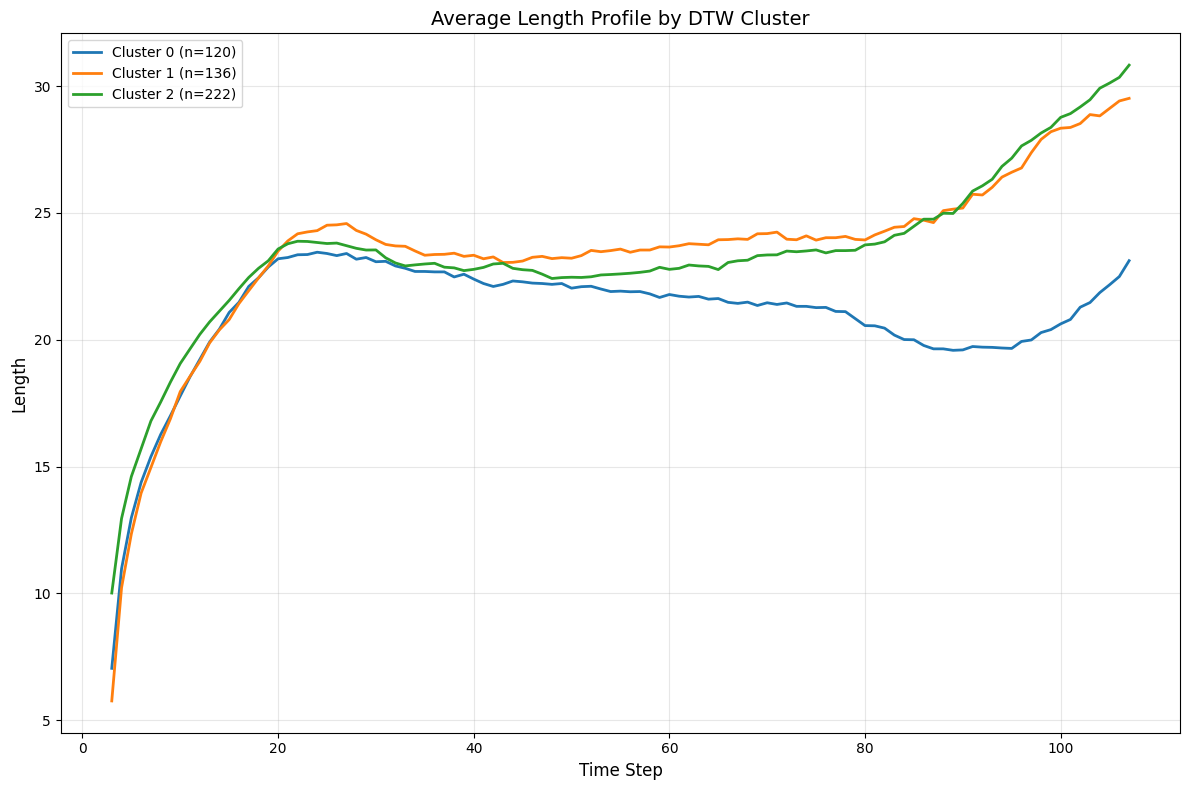

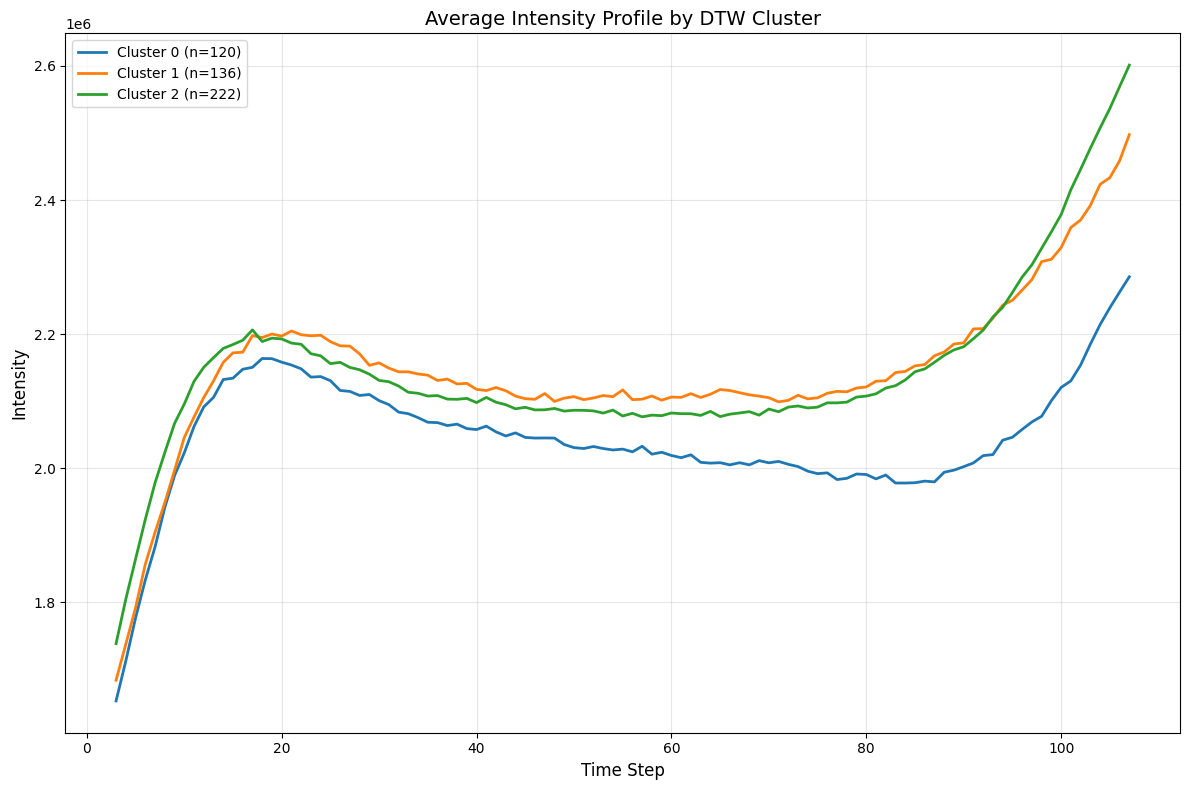

In [23]:
# Plot average profiles for each feature type
for feature_name, feature_data, centroids_orig in [
    ('Width', width_data, width_centroids_orig),
    ('Length', length_data, length_centroids_orig),
    ('Intensity', intensity_data, intensity_centroids_orig)
]:
    plt.figure(figsize=(12, 8))
    for cluster_id in range(optimal_k):
        # Get indices of samples in this cluster
        cluster_indices = np.where(cluster_labels == cluster_id)[0]
        if len(cluster_indices) == 0:
            continue  # Skip if cluster is empty

        # Calculate the mean profile for this cluster
        cluster_data = feature_data.iloc[cluster_indices]
        cluster_mean_profile = cluster_data.mean(axis=0)

        # Plot the mean profile
        plt.plot(cluster_mean_profile, label=f'Cluster {cluster_id} (n={len(cluster_indices)})', linewidth=2)

    plt.xlabel('Time Step', fontsize=12)
    plt.ylabel(feature_name, fontsize=12)
    plt.title(f'Average {feature_name} Profile by DTW Cluster', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()